#

In [1]:
# To begin with, I will list the attributes that I deem important that could help better detect the fraud 
# First: Transaction amount-----relatively larger amount could have the risk of being fraudulant
# Second: Transaction Type: Debit and Credit could have a big influence
# TransactionDurationg---- longer time might indicate anomolies
# LoginAttempt    ------- larger login attemps might have a higher risk
# CustomerAge   ------- The age of customer might have an influence (for example, people above 60 might easily encounter fradulent cases)

# First we do the data loading and visualization part
import pandas as pd
import numpy as np
df = pd.read_csv("bank-transactions.csv")

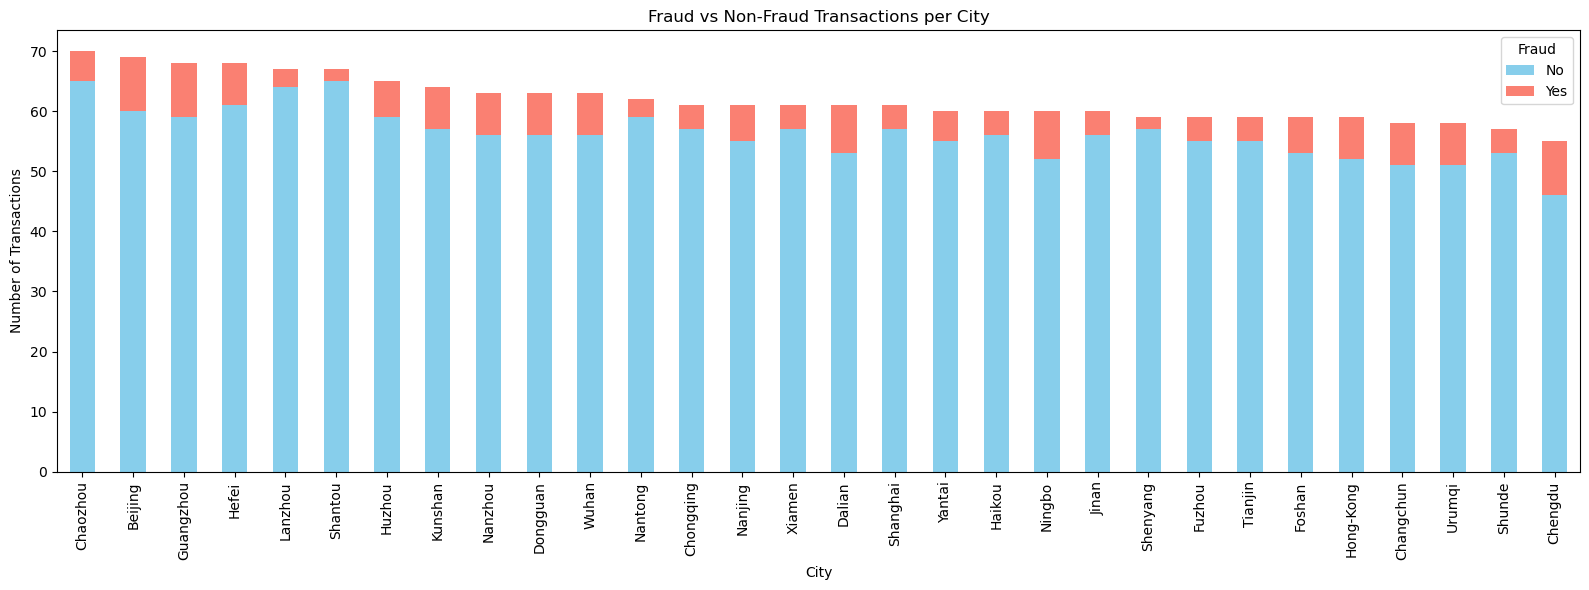

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# Here,we create a new object and calls its function size to make it become a dataframe and then unstack here turns the row attribute to column for better alignment.
city_fraud_counts = df.groupby(['Location', 'Fraud']).size().unstack(fill_value=0)
top_cities = df['Location'].value_counts().head(30).index
city_fraud_counts = city_fraud_counts.loc[top_cities] # Here we only choose top 30 cities that appear most in the dataset 
plt.figure(figsize=(16, 6))
city_fraud_counts.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], ax=plt.gca())
plt.xlabel('City')
plt.ylabel('Number of Transactions')
plt.title('Fraud vs Non-Fraud Transactions per City')
plt.legend(title='Fraud', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()
# Here we can see basically how many fraud cases happen in each cities(whenever there are transactions)
# The red part is approximately the number of fraud cases, for example Chaozhou appears most in the dataset, and approximately(red block)

Text(0.5, 1.02, 'Scatter Matrix of Key Features Colored by Fraud Label (Yellow = Fraud)')

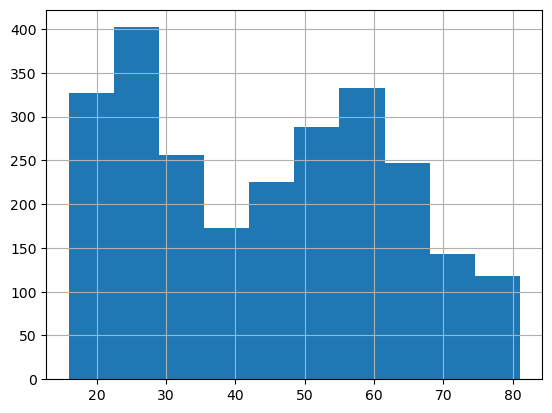

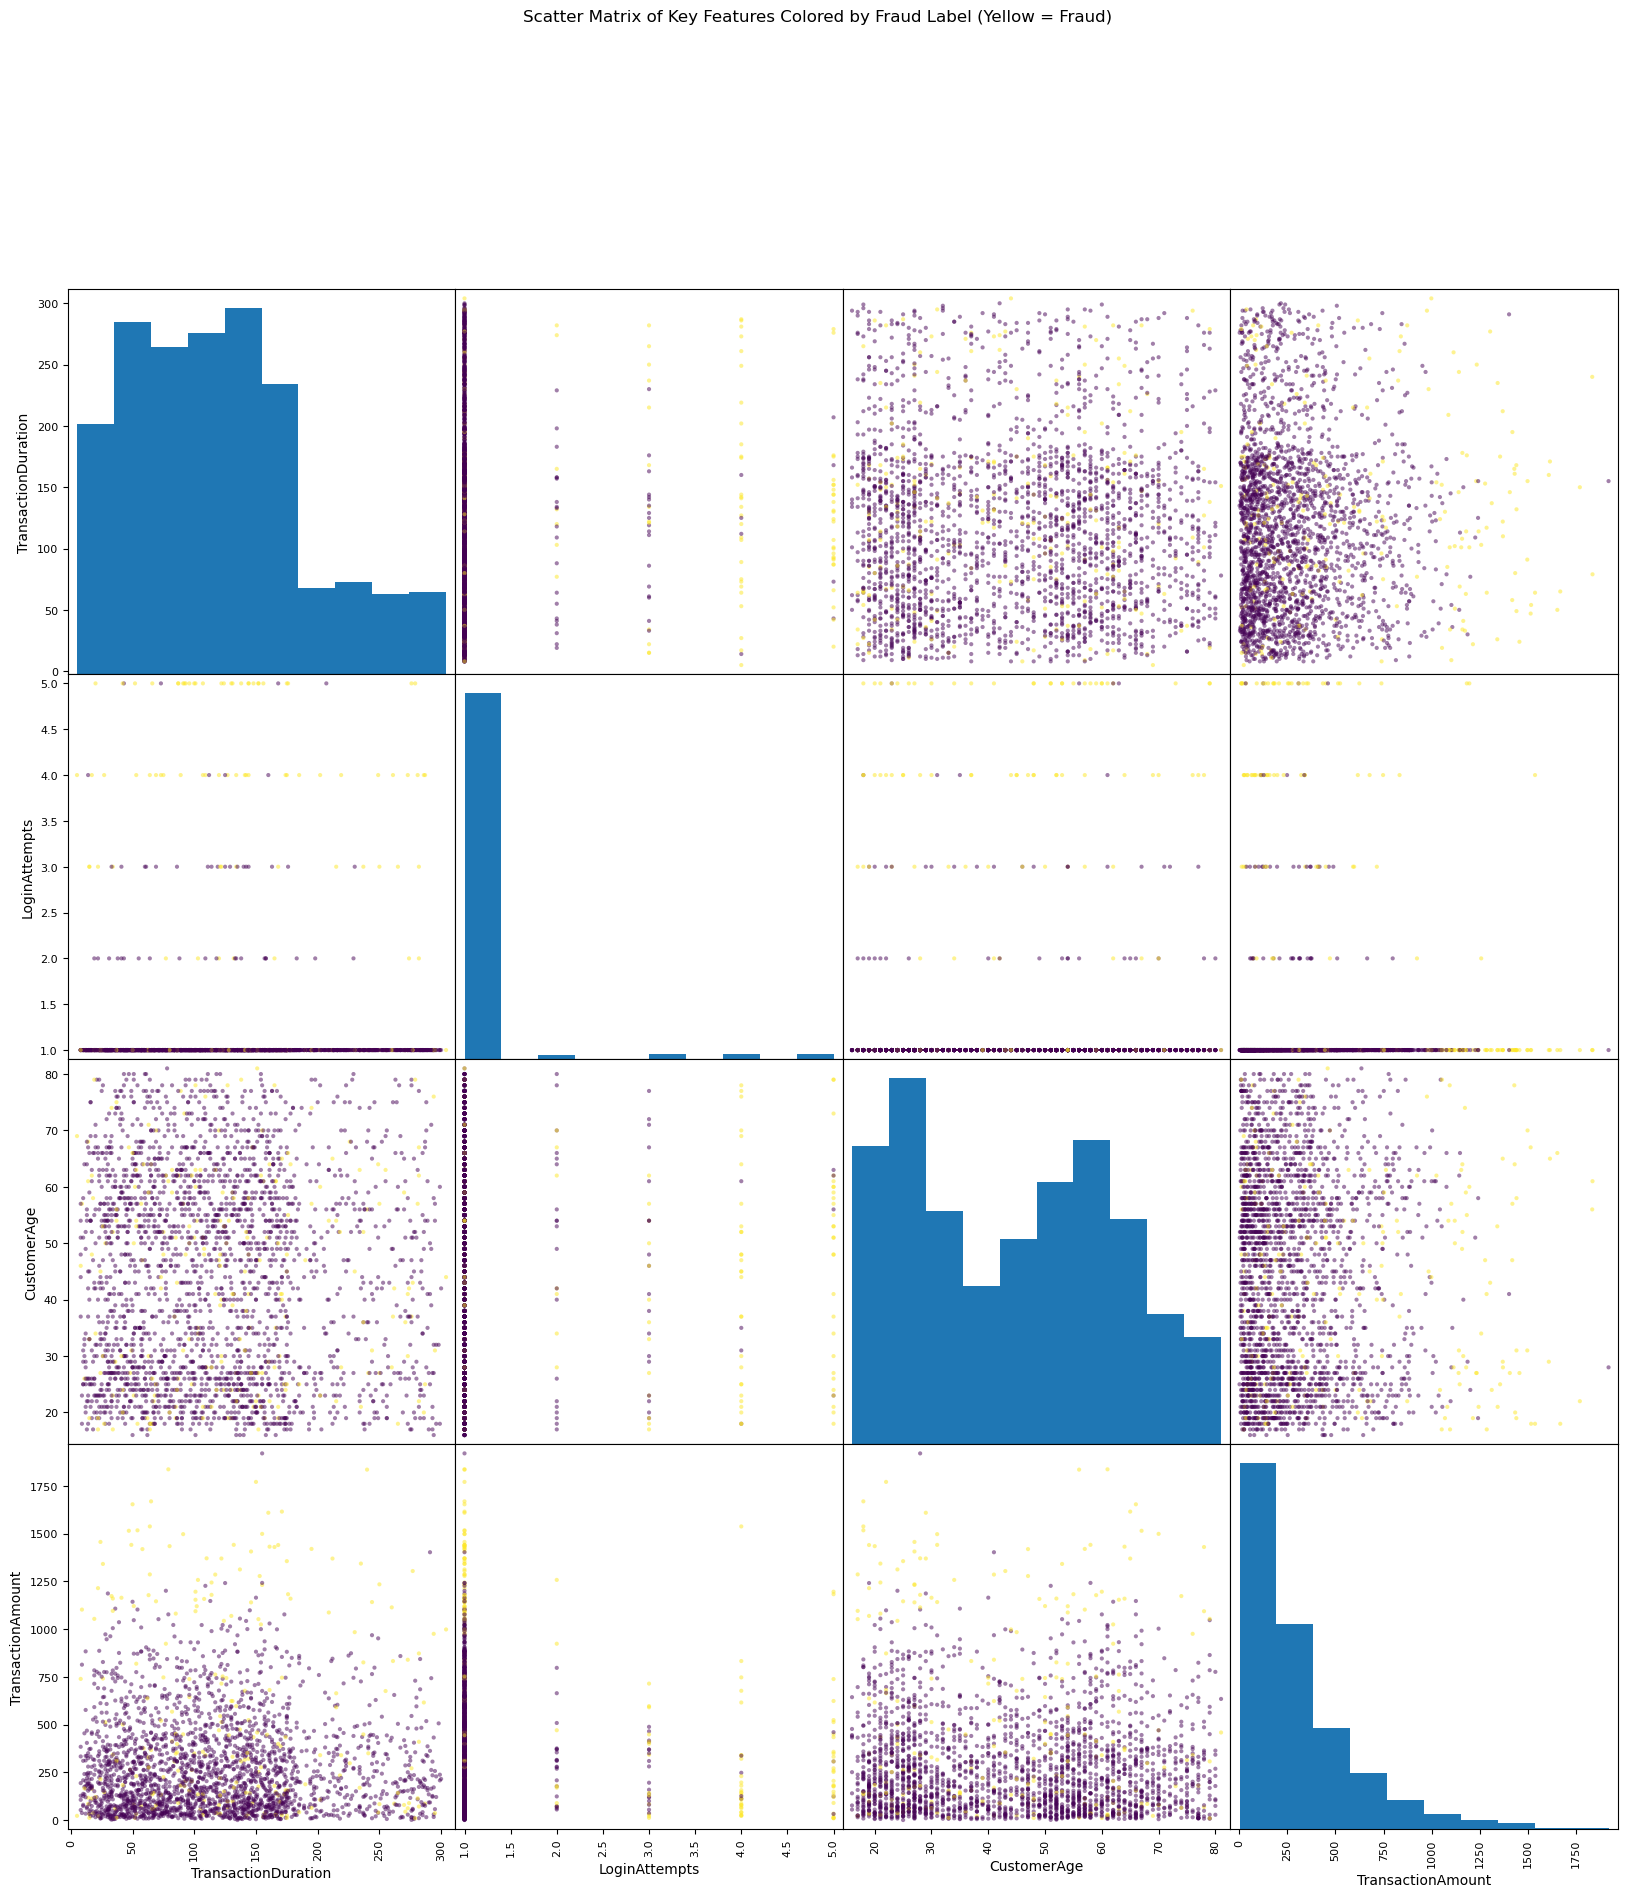

In [3]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
df['CustomerAge'].hist()
y = df['Fraud']
X = df[['TransactionDuration','LoginAttempts','CustomerAge','TransactionAmount']]
scatter_matrix(X, c = y, figsize = [20,20])
plt.suptitle("Scatter Matrix of Key Features Colored by Fraud Label (Yellow = Fraud)", y=1.02)
# Here I use the things leant in class, the scatter matrix to visualize the data, the yellow one is the case when it is fraud. 
# From the data visualization, you can have a clear sense that for example when LoginAttemps is larger, the more likely it is a fraudulaent case
# What's more, when transaction amount is bigger than some limit, the more likely it is the fraudulent case. 


In [4]:
# You can see here, when LoginAttempts is bigger, more likely there is a fraud case.  
# You can also see here for the TransactionAmound, it is clearly that when transaction amount is bigger(let's say bigger than 1250), almost the fraud cases occur.

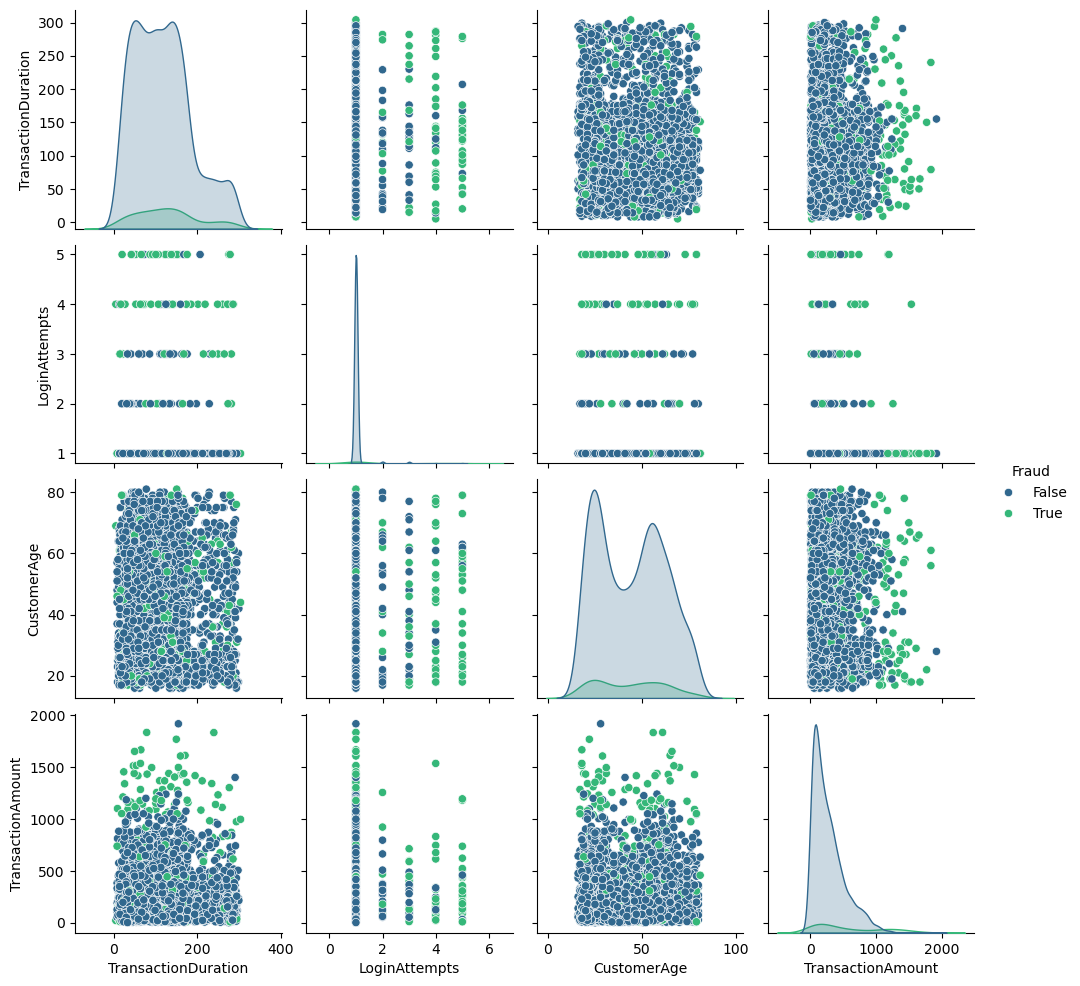

In [5]:
# Again, I want to use the seaborn lib to better visualize the data. this function pairplot could automatically plot the graph with the colored label.
import seaborn as sns
sns.pairplot(df[['TransactionDuration','LoginAttempts','CustomerAge','TransactionAmount','Fraud','TransactionType']], 
             hue='Fraud', palette='viridis')
# This is for better visualization

In [6]:
df.groupby('Fraud')[['TransactionAmount', 'LoginAttempts']].describe()
# Here, we use the technique learnt in lab, the describe function to see how closely transationAmount, loginAttempts assosiate with Fraud Cases
# You can see clearly that fraud cases their 75 percent position, Quarter3(75%) value is abnormaly larger compared with true cases, which indicate more transaction amount and loginattempts might have an influence. 

TransactionAmount                                                 \
                  count        mean         std   min      25%     50%   
Fraud                                                                    
False            2280.0  274.570658  242.341909   1.0   83.400  207.35   
True              232.0  577.018103  513.445244  10.4  134.475  371.80   

                        LoginAttempts                                          \
            75%     max         count      mean       std  min  25%  50%  75%   
Fraud                                                                           
False   389.075  1919.5        2280.0  1.036842  0.287905  1.0  1.0  1.0  1.0   
True   1082.650  1836.1         232.0  1.987069  1.518944  1.0  1.0  1.0  3.0   

            
       max  
Fraud       
False  5.0  
True   5.0

In [7]:
# data cleaning, I find that immediately using the data, convert it to 0 and 1 has a problem, perhaps because of space or indentation
df['Fraud'] = df['Fraud'].astype(str).str.strip().str.upper().map({'FALSE': 0, 'TRUE': 1})
df['TransactionType'] = df['TransactionType'].astype(str).str.strip().str.upper().map({'CREDIT': 0, 'DEBIT': 1})
print(df['Fraud'].value_counts())
print(df['TransactionType'].value_counts())


Fraud
0    2280
1     232
Name: count, dtype: int64
TransactionType
1    1944
0     568
Name: count, dtype: int64


In [8]:
# Now we continue with data preprocessing, to build the model, I would like to use attributes: 
# Attributes: Transaction amount, Transaction Type(Debit and Credit) TransactionDuration, LoginAttempt , CustomerAge   
# First we deal with the Y , the Fraud attributes, changing it to binary discrete outcome
# 
import numpy as np
x1 = df['TransactionAmount'].values
x3 = df['TransactionDuration'].values
x4 = df['LoginAttempts'].values
x5 = df['CustomerAge'].values
X = np.concatenate([x1.reshape(-1,1),  x3.reshape(-1,1), x4.reshape(-1,1),x5.reshape(-1,1)], axis = 1)
y = df['Fraud'].values

print(y)

print(df['TransactionType'])
print(df['Fraud'].value_counts())
# Here just to get a sense how many fraud cases there are.


[0 0 0 ... 0 0 0]
0       1
1       0
2       1
3       1
4       1
       ..
2507    0
2508    1
2509    1
2510    1
2511    1
Name: TransactionType, Length: 2512, dtype: int64
Fraud
0    2280
1     232
Name: count, dtype: int64


In [9]:
# We first divide the training and testing datasets first. 
# Also, in the training dataset, we also divide it to make a validation dataset for our model choosing.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


# This is to divide the dataset into whole training dataset and testing dataset
X_train_sum, X_test, y_train_sum, y_test = train_test_split(X, y,
test_size=0.2,
random_state = 202)
# Here is to divide the whole training dataset into actual training dataset(before evalution on testing dataset, this is for choosing the model(for example, hypertuning, the selesction of certain parameters) and validatio dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_sum, y_train_sum, test_size = 0.2, random_state = 44)

# Here we normalize the training datasets.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Here we use the taining dataset's mean and variance for the scaling
X_test = scaler.transform(X_test)
X_train_sum = scaler.transform(X_train_sum)
lr = LogisticRegression(max_iter =1000)
lr.fit(X_train, y_train)
lr.score(X_train, y_train)
X_val = scaler.transform(X_val)
# Here we derive the result, it is relatively good. Now let's see the details of it

y_pred = lr.predict(X_val)
print(classification_report(y_val, y_pred))

# We can see that for the fraud cases, we only have an recall rate of 35 percent,we only predicts rightly the 35 percent of total fraud cases, which is quite low. 
# Here precision means that: the percentage of the cases you predict are actually in this class.We get quite good precision, that's good. 
# The recall means: Among all the class samples, how much percentage you have predict right




              precision    recall  f1-score   support

           0       0.92      0.99      0.96       356
           1       0.84      0.35      0.49        46

    accuracy                           0.92       402
   macro avg       0.88      0.67      0.72       402
weighted avg       0.91      0.92      0.90       402



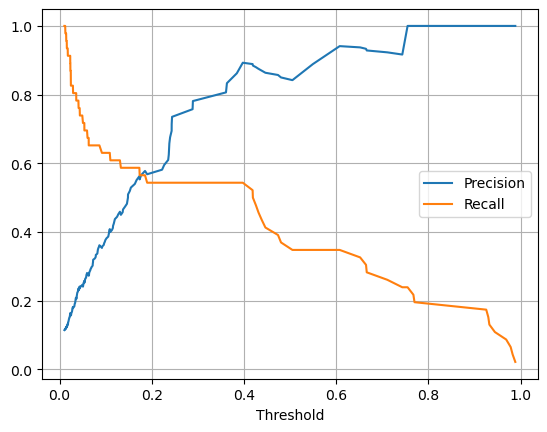

In [10]:
# Next I think about to which extent do I adjust the threshold would make the model perform better, and therefore, I choose to make a continuous graph to represent this.
from sklearn.metrics import precision_recall_curve, roc_curve
y_prob = lr.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
# Here, try to use precision[:-1] or recall[:-1] is for alignment 
# The logic here is to list all the probability that calculated by sigmoid inner function, and mark them from 0 to be the threshold. and based on the certain threshold, we reclassify
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.grid()
# HEre, we can see that around 0.2 is probably the best way to balance both precision and recall.

In [11]:
# Here we try to make the threshold around 0.61 and print out the performance
from sklearn.metrics import classification_report
y_proba = lr.predict_proba(X_val)[:, 1]
y_pred_adjusted = (y_proba >= 0.2).astype(int)
print(classification_report(y_val, y_pred_adjusted))
# Here we can see it's getting worse on precision but better on recall, which is the percentage that is sucessfully reported in the sample featured "fraud"
# This is actually a trade-off, we would rather think more would be fraud, than let the fraud case slip. 

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       356
           1       0.58      0.54      0.56        46

    accuracy                           0.90       402
   macro avg       0.76      0.75      0.75       402
weighted avg       0.90      0.90      0.90       402



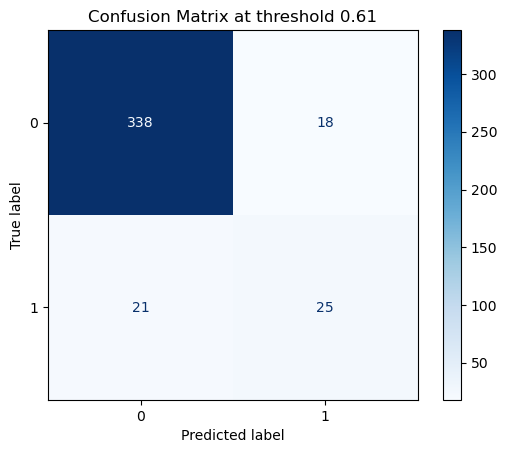

In [12]:
# Based on what we learnt in class， this is a confusion matrix to show the True Positive, False Positive, False Negative, True Negative. 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_val, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix at threshold 0.61")
plt.show()


In [13]:
# Now let us change a way to think about this
# Here we try to activate some parameters of the logistic regression, we adjust the weight and let us see which weight is better. 
gather = [1,2,3,4,5,6,7,8]
for i in gather:
    lr = LogisticRegression(class_weight={0: 1, 1: i})
    lr.fit(X_train, y_train)
    y_predd = lr.predict(X_val)
    print("This is for weight",i)
    print("\n")
    print(classification_report(y_val, y_predd))


This is for weight 1


              precision    recall  f1-score   support

           0       0.92      0.99      0.96       356
           1       0.84      0.35      0.49        46

    accuracy                           0.92       402
   macro avg       0.88      0.67      0.72       402
weighted avg       0.91      0.92      0.90       402

This is for weight 2


              precision    recall  f1-score   support

           0       0.94      0.99      0.96       356
           1       0.83      0.54      0.66        46

    accuracy                           0.94       402
   macro avg       0.89      0.76      0.81       402
weighted avg       0.93      0.94      0.93       402

This is for weight 3


              precision    recall  f1-score   support

           0       0.94      0.98      0.96       356
           1       0.78      0.54      0.64        46

    accuracy                           0.93       402
   macro avg       0.86      0.76      0.80       402
weigh

In [14]:
# Let's try to adjust different threshold to see which one is better 
# We define the threshold ourselves. 
y_proba = lr.predict_proba(X_val)[:, 1]
test = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]
for i in test: 
    y_pred_adjusted = (y_proba >= i).astype(int)
    print("This is for", i, "\n")
    print(classification_report(y_val,y_pred_adjusted))

This is for 0.3 

              precision    recall  f1-score   support

           0       0.95      0.71      0.81       356
           1       0.24      0.72      0.36        46

    accuracy                           0.71       402
   macro avg       0.60      0.71      0.59       402
weighted avg       0.87      0.71      0.76       402

This is for 0.4 

              precision    recall  f1-score   support

           0       0.95      0.84      0.89       356
           1       0.34      0.63      0.44        46

    accuracy                           0.82       402
   macro avg       0.64      0.74      0.66       402
weighted avg       0.88      0.82      0.84       402

This is for 0.45 

              precision    recall  f1-score   support

           0       0.95      0.86      0.90       356
           1       0.37      0.63      0.47        46

    accuracy                           0.84       402
   macro avg       0.66      0.75      0.69       402
weighted avg       

In [15]:
# Next we try different linear model, consider feature engineering
a = x1.reshape(-1,1)
b = x3.reshape(-1,1)
c = x4.reshape(-1,1)
d = x5.reshape(-1,1)
X = np.concatenate([a,b,c,d,a*a,b*b,c*c,d*d,a*b,a*c,a*d,b*c,b*d,c*d],axis = 1)
y = df['Fraud'].values
X_train_sum, X_test, y_train_sum, y_test = train_test_split(X, y,
test_size=0.2,
random_state = 202)
# Here is to divide the whole training dataset into actual training dataset(before evalution on testing dataset, this is for choosing the model(for example, hypertuning, the selesction of certain parameters) and validatio dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_sum, y_train_sum, test_size = 0.2, random_state = 44)

# Here we normalize the training datasets.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Here we use the taining dataset's mean and variance for the scaling
X_test = scaler.transform(X_test)
X_train_sum = scaler.transform(X_train_sum)
lr = LogisticRegression(max_iter =1000, class_weight = {0:1,1:2})
lr.fit(X_train, y_train)
lr.score(X_train, y_train)
X_val = scaler.transform(X_val)
# Here we derive the result, it is relatively good. Now let's see the details of it

y_pred = lr.predict(X_val)
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.99      0.97       356
           1       0.86      0.54      0.67        46

    accuracy                           0.94       402
   macro avg       0.90      0.77      0.82       402
weighted avg       0.93      0.94      0.93       402



In [16]:
# Here I list all the possible combination and try to recognize which one is better after feature engineering.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
gather = [1, 2, 3, 4, 5, 6, 7, 8]
test = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]

for i in gather:
    for j in test: 
        lr = LogisticRegression(class_weight={0: 1, 1: i}, max_iter=1000)
        lr.fit(X_train, y_train)
        y_proba = lr.predict_proba(X_val)[:, 1]  #
        y_pred_adjusted = (y_proba >= j).astype(int)

        print("This is for weight", i, "threshold", j)
        print(classification_report(y_val, y_pred_adjusted))
        print("\n" + "="*60 + "\n")


This is for weight 1 threshold 0.3
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       356
           1       0.81      0.54      0.65        46

    accuracy                           0.93       402
   macro avg       0.87      0.76      0.81       402
weighted avg       0.93      0.93      0.93       402



This is for weight 1 threshold 0.4
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       356
           1       0.92      0.52      0.67        46

    accuracy                           0.94       402
   macro avg       0.93      0.76      0.82       402
weighted avg       0.94      0.94      0.93       402



This is for weight 1 threshold 0.45
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       356
           1       0.92      0.52      0.67        46

    accuracy                           0.94       402
   macro avg      

In [17]:
# use K fold validation on training datasets to see how it performs
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import cross_val_score
warnings.filterwarnings("ignore", category=ConvergenceWarning)
lr = LogisticRegression(class_weight={0: 1, 1: 2}, max_iter = 10000)
scores = cross_val_score(lr, X_train_sum, y_train_sum, cv=5, scoring='f1')
print("Each fold f1:", scores)
print("Average f1:", scores.mean())
# It is relatively good.

Each fold f1: [0.55737705 0.69565217 0.67647059 0.72727273 0.5915493 ]
Average f1: 0.6496643668752082


In [18]:
# After feature engineering we get the model perform better, so let us keep in this way. After trying different sets of combination
# We could see some options a): Weight 1, threshold 0.5, precision:0.92, recall 0.52, f1-score 0.67
# option2  Weight2 threshold 0.55, Precision 0.89, Recall 0.54, f1-score 0.68.
# Here I think option 2 is better, so we keep in this way.
# Here we begin to test on our testing dataset.
lr = LogisticRegression(class_weight={0: 1, 1: 2}, max_iter=1000)
lr.fit(X_train_sum, y_train_sum)
y_proba = lr.predict_proba(X_test)[:, 1]  #
y_pred_adjusted = (y_proba >= 0.55).astype(int)
print(classification_report(y_test, y_pred_adjusted))
print("\n" + "="*60 + "\n")
# We can see on our testing dataset it is good but still could be improved .

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       463
           1       0.74      0.42      0.54        40

    accuracy                           0.94       503
   macro avg       0.85      0.71      0.75       503
weighted avg       0.94      0.94      0.94       503





In [19]:
# final evaluation 
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics import roc_auc_score
# Note AUC score here means how strong it is to help predict positive case, how good it is to do the classification or you can say distinguishment. 
print("AUC score:", roc_auc_score(y_test, y_proba))
cm = confusion_matrix(y_test, y_pred_adjusted)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, None] * 100
print("Confusion Matrix (%):")
print(np.round(cm_percent, 2))
# not bad auc score.

AUC score: 0.7142008639308856
Confusion Matrix (%):
[[98.7  1.3]
 [57.5 42.5]]


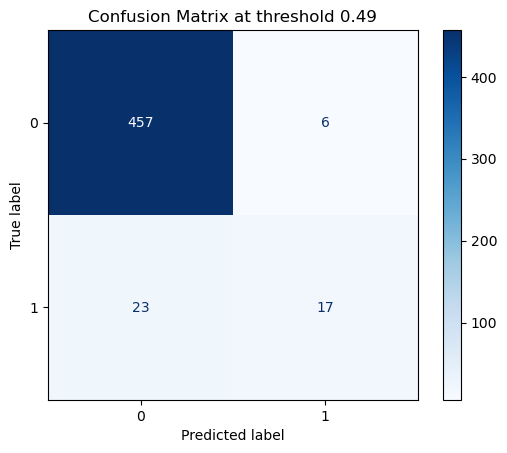

In [20]:
# Here we tru to visualize the matrix in a more intuitive way. 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix at threshold 0.49")
plt.show()

In [21]:
# Inspired in class, I consider whether neural network has such a classifier that utilizes the property of neural network to do the classfication
# Turns out there is a classifier like this : MLPClassifier.
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    random_state=42)
mlp.fit(X_train_sum, y_train_sum)
y_pred = mlp.predict(X_test)
print(classification_report(y_test, y_pred))
# For class "1" we only have precision 0.7 and recall 0.35 which performs poorly compared with our logistic regression model

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       463
           1       0.70      0.35      0.47        40

    accuracy                           0.94       503
   macro avg       0.82      0.67      0.72       503
weighted avg       0.93      0.94      0.93       503



In [22]:
y_prob = mlp.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.4).astype(int)
print(classification_report(y_test, y_pred))
# after trying to use MLPclassifier to try with this classification problem, things don't work pretty well, after comparison, it is better to use the logistci regrssion model. 



              precision    recall  f1-score   support

           0       0.95      0.98      0.97       463
           1       0.68      0.38      0.48        40

    accuracy                           0.94       503
   macro avg       0.81      0.68      0.72       503
weighted avg       0.93      0.94      0.93       503



In [23]:
# Conclusion: we derive this model evaluate on the testing dataset. ALthough to some degrees it is accurate in predicting fraud cases
# However, it only predicts merely 40 percent of all fraud cases, 
# The reasons I think could be: samples are too small, the cases when there are fraud cases are too limited, weights need to be reemphasized in a different way
# limitations of logistic regression model
# There might be more informative variables yet not been offered. for example: what type of products they are buying